__Markus Mulvihill__

__Last updated April 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib

# Introduction

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

In [ ]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

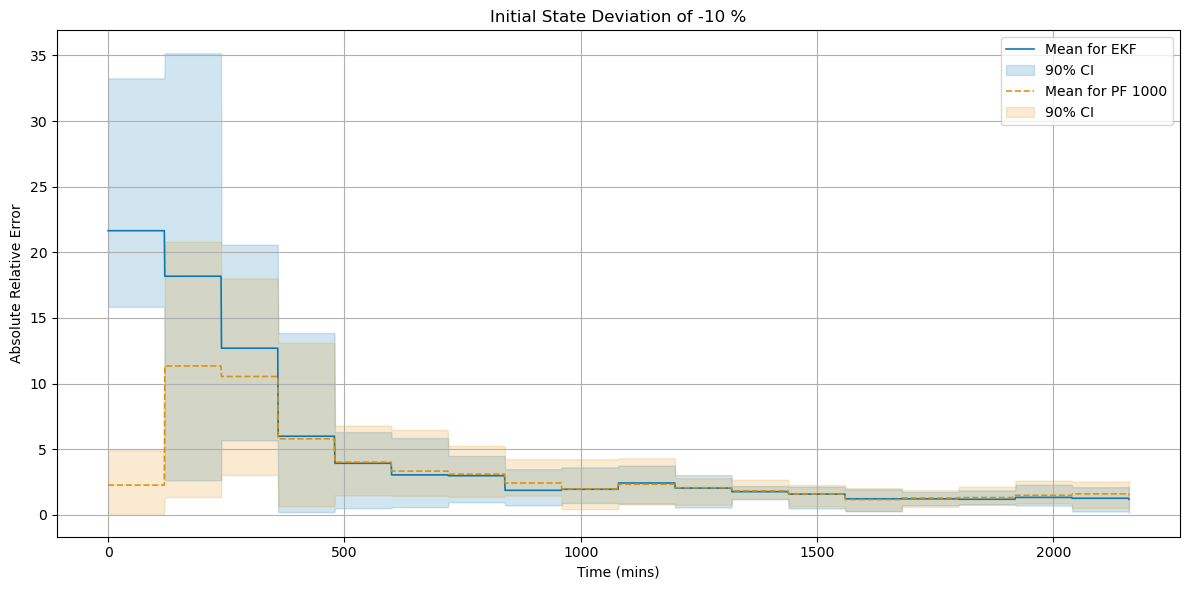

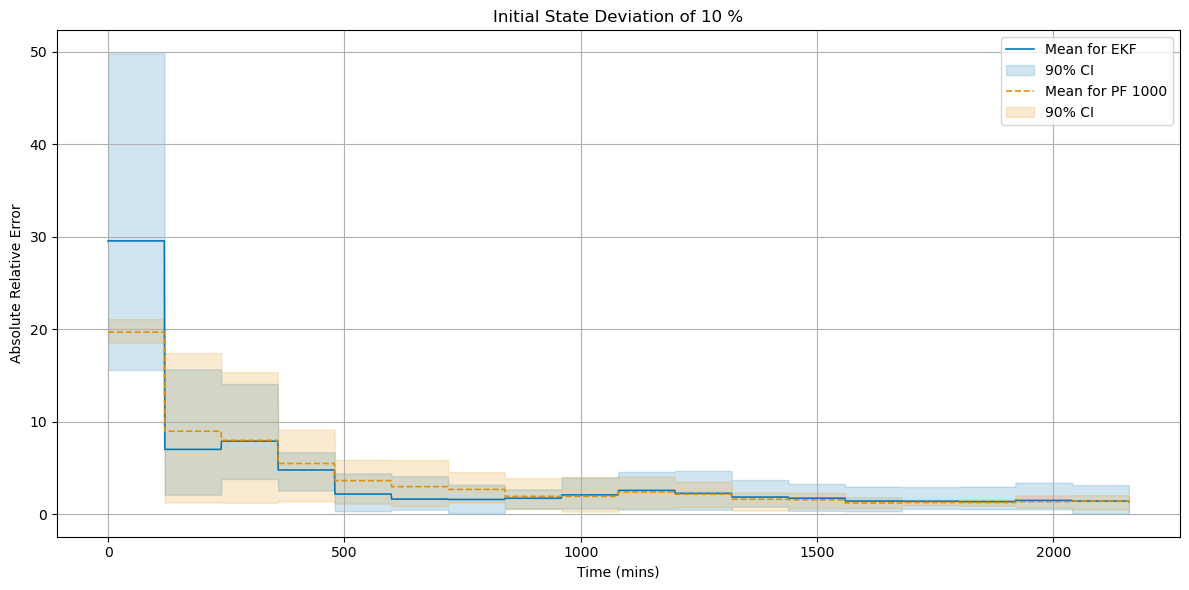

In [4]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j,:, :, :], axis=1)
    ci_low = np.percentile(SI_errs[j,:, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j,:, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )
        ax.fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18, label=f"{CI}% CI")
    ax.set_ylabel("Absolute Relative Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax.grid()
    fig.tight_layout()